# 04 — Linear Regression

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 4 of 20**

This is the first *algorithm* notebook in the sprint — everything in Notebooks 1-3 was about how to
think about ML and how to evaluate it honestly. From here on we implement, one algorithm at a time,
starting with the simplest and most interpretable: Linear Regression.

**Dataset:** `sklearn.datasets.load_diabetes` (regression, fully bundled, no network download —
continuing from Notebook 3 for the same offline-reproducibility reason). Swap in
`fetch_california_housing(as_frame=True)` on your own machine if you want to re-run this against your
housing project's dataset instead — nothing about the method changes.


## 1. What is Regression?

Regression is the supervised-learning task of predicting a **continuous numeric target** from one or
more input features (Notebook 1, Section 5). "How much", "how many", "what value" questions —
house price, temperature, disease progression score — are regression questions.

## 2. Linear Regression — the core idea

Linear Regression assumes the target is (approximately) a **weighted sum of the features, plus a
constant**:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

- $\hat{y}$ — the predicted value
- $\theta_0$ — the **intercept** (bias): the predicted value when every feature is 0
- $\theta_1, \dots, \theta_n$ — the **coefficients** (weights): how much $\hat{y}$ changes for a
  one-unit increase in that feature, holding the others fixed
- $x_1, \dots, x_n$ — the **independent variables** (features)
- $\hat{y}$ (or $y$ for the true value) — the **dependent variable** (target): "dependent" because we
  model it as depending on the $x$'s

**Simple Linear Regression**: one feature ($\hat{y} = \theta_0 + \theta_1 x$ — a straight line in 2D).
**Multiple Linear Regression**: more than one feature (a hyperplane in higher dimensions — same idea,
just not something you can sketch on paper past 2 features).

**Why is it required / what problem does it solve?** It gives a simple, fast, highly interpretable
baseline for any regression problem — every coefficient has a direct, readable meaning ("each extra
bedroom is associated with +$12,400"), which most other, more powerful models don't offer as cleanly.

**Assumptions:**
- The relationship between features and target is (approximately) linear.
- Features aren't too strongly correlated with each other (severe multicollinearity makes individual
  coefficients unstable/unreliable, even if overall predictions stay fine).
- Residuals (errors) are roughly independent, have constant variance (homoscedasticity), and are
  roughly normally distributed (matters most for statistical inference on the coefficients, less for
  pure prediction).

**When to use it:** as a fast, interpretable baseline for any regression problem — always worth fitting
one before reaching for something more complex, if only to know what "better than nothing" looks like.
**When not to use it:** when the true relationship is strongly non-linear (a plain straight-line model
will systematically underfit) or when you need to model interactions/thresholds that a single linear
equation can't represent without heavy feature engineering.


## 3. Residuals, Least Squares, and the Cost Function

For any candidate line, the **residual** for a training example is the gap between the true value and
the line's prediction: $e_i = y_i - \hat{y}_i$. A good line has small residuals, on average, across all
training points.

**Why not just minimize the sum of residuals directly?** Positive and negative residuals would cancel
out — a line could have huge errors in both directions and still sum to zero. Instead we minimize the
**sum of squared residuals** (squaring removes the sign issue and heavily penalizes large errors):

$$J(\theta) = \frac{1}{m}\sum_{i=1}^{m} \left(\hat{y}_i - y_i\right)^2 \quad \text{(Mean Squared Error — the cost/loss function)}$$

This is the **Least Squares** method: find the $\theta$ values that minimize $J(\theta)$. It has two
common solutions:
1. **The Normal Equation** — a closed-form formula that directly computes the optimal $\theta$ in one
   step (Section 5 below implements this by hand).
2. **Gradient Descent** — an iterative search that nudges $\theta$ downhill on the cost surface a little
   at a time (Section 6 below).


Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape: (442, 10) (442,)


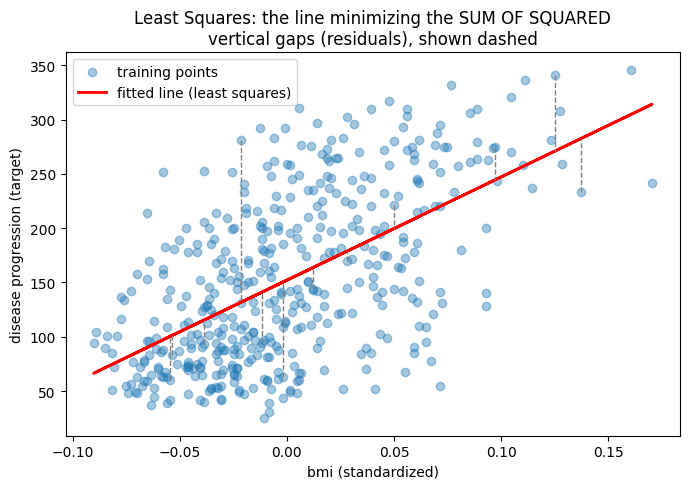


Simple Linear Regression on bmi alone:
  intercept (theta_0) = 152.13
  coefficient (theta_1) = 949.44
  -> interpretation: for every 1-unit increase in standardized bmi, predicted disease
     progression increases by about 949.4, holding nothing else constant
     (only one feature is used here, so there's nothing else to hold constant yet).


In [1]:
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target
print("Features:", list(X.columns))
print("Shape:", X.shape, y.shape)

# Use a single feature (bmi) for a 2D visualization of "what least squares is actually doing"
x_bmi = X["bmi"].values
from sklearn.linear_model import LinearRegression
simple = LinearRegression().fit(x_bmi.reshape(-1, 1), y)
y_pred = simple.predict(x_bmi.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_bmi, y, alpha=0.4, label="training points")
ax.plot(x_bmi, y_pred, color="red", linewidth=2, label="fitted line (least squares)")
# draw a handful of residuals as vertical dashed lines
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(x_bmi), size=12, replace=False)
for i in sample_idx:
    ax.plot([x_bmi[i], x_bmi[i]], [y.values[i], y_pred[i]], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("bmi (standardized)")
ax.set_ylabel("disease progression (target)")
ax.set_title("Least Squares: the line minimizing the SUM OF SQUARED\nvertical gaps (residuals), shown dashed")
ax.legend()
plt.tight_layout()
plt.savefig("residuals.png", dpi=120)
plt.show()

print(f"\nSimple Linear Regression on bmi alone:")
print(f"  intercept (theta_0) = {simple.intercept_:.2f}")
print(f"  coefficient (theta_1) = {simple.coef_[0]:.2f}")
print(f"  -> interpretation: for every 1-unit increase in standardized bmi, predicted disease")
print(f"     progression increases by about {simple.coef_[0]:.1f}, holding nothing else constant")
print(f"     (only one feature is used here, so there's nothing else to hold constant yet).")


## 4. Multiple Linear Regression with scikit-learn


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Intercept (theta_0):", round(model.intercept_, 2))
print("\nCoefficients (theta_1 ... theta_n), sorted by magnitude:")
print(coef_table.round(2))

y_pred = model.predict(X_test)
print(f"\nTest RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.3f}")


Intercept (theta_0): 151.35

Coefficients (theta_1 ... theta_n), sorted by magnitude:
s1    -931.49
s5     736.20
bmi    542.43
s2     518.06
bp     347.70
s4     275.32
sex   -241.96
s3     163.42
s6      48.67
age     37.90
dtype: float64

Test RMSE: 53.85
Test R²:   0.453


**Reading the coefficients:** `s5` (a blood serum measurement) has the largest-magnitude
coefficient here — meaning, holding every other feature constant, it's associated with the biggest
swing in predicted disease progression per unit change. This is exactly why Linear Regression's
interpretability is valuable: you can say *which* features are driving predictions and in *which
direction*, something you can't read directly off a Random Forest or a neural net without extra tooling.

A quick sanity check on the metrics themselves: **RMSE** is in the same units as the target (disease
progression score) — "typically off by about this much." **R²** is unitless, roughly "fraction of the
target's variance explained by the model" (1.0 = perfect, 0.0 = no better than always predicting the
mean; it can go negative if the model is worse than that). Full treatment of both is Notebook 13.


## 5. The Normal Equation — implementing the math with NumPy

Rather than trusting `LinearRegression()` as a black box, let's derive the same coefficients ourselves.
Minimizing $J(\theta)$ from Section 3 with calculus (setting its gradient to zero and solving) gives a
closed-form solution — the **Normal Equation**:

$$\theta = (X^T X)^{-1} X^T y$$

where $X$ has an extra column of 1's prepended (so the intercept $\theta_0$ falls out of the same
matrix multiplication, rather than needing separate handling).


In [3]:
import numpy as np

# Build X with a leading column of 1's (the "bias trick") so theta_0 (intercept) comes out
# of the same equation as the other coefficients.
X_train_np = X_train.values
X_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]   # shape: (m, n_features + 1)
y_train_np = y_train.values

# Normal Equation: theta = (X^T X)^-1 X^T y
theta_normal_eq = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train_np

print("theta_0 (intercept) from Normal Equation: ", round(theta_normal_eq[0], 2))
print("theta_0 (intercept) from sklearn:         ", round(model.intercept_, 2))

print("\nFirst 3 coefficients, Normal Equation vs sklearn:")
for name, manual, sk in list(zip(X.columns, theta_normal_eq[1:], model.coef_))[:3]:
    print(f"  {name:>4}:  manual = {manual:8.2f}   sklearn = {sk:8.2f}")

print("\nAll close?", np.allclose(theta_normal_eq[1:], model.coef_) and np.isclose(theta_normal_eq[0], model.intercept_))
print("-> scikit-learn's LinearRegression IS solving exactly this equation internally (via an SVD-based")
print("   solver for numerical stability, but the underlying math is identical).")


theta_0 (intercept) from Normal Equation:  151.35
theta_0 (intercept) from sklearn:          151.35

First 3 coefficients, Normal Equation vs sklearn:
   age:  manual =    37.90   sklearn =    37.90
   sex:  manual =  -241.96   sklearn =  -241.96
   bmi:  manual =   542.43   sklearn =   542.43

All close? True
-> scikit-learn's LinearRegression IS solving exactly this equation internally (via an SVD-based
   solver for numerical stability, but the underlying math is identical).


## 6. Gradient Descent — Introduction

The Normal Equation is exact, but computing $(X^T X)^{-1}$ gets computationally expensive as the number
of features grows large (it's roughly $O(n^3)$), and it doesn't work at all for models that don't have
a closed-form solution (like most of what comes later in this sprint — Logistic Regression, neural
networks, ...). **Gradient Descent** is a general-purpose alternative that works for *any*
differentiable cost function:

1. Start with random values for $\theta$.
2. Compute the **gradient** of $J(\theta)$ — the direction of steepest *increase* in the cost.
3. Take a small step in the *opposite* direction (steepest *decrease*): $\theta \leftarrow \theta -
   \alpha \nabla J(\theta)$, where $\alpha$ is the **learning rate**.
4. Repeat until the cost stops meaningfully decreasing (convergence).

The learning rate $\alpha$ matters a lot: too small and training crawls; too large and it can overshoot
the minimum and diverge instead of converging. (This sprint doesn't require memorizing the gradient
formula itself — the goal here is the *intuition*: rolling downhill on the cost surface, one small step
at a time. Gradient Descent variants get a deeper treatment in your Task 7 material on Training Models.)


theta from Gradient Descent:      [152.13  45.16]
theta from Normal Equation:       [152.13  45.16]

-> with the feature properly scaled, Gradient Descent converges to (essentially) the exact
   same answer as the closed-form solution.


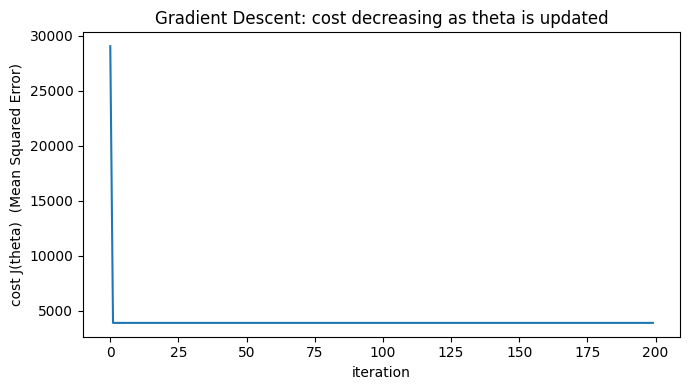

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Tiny hand-rolled Gradient Descent on the SAME single-feature (bmi) problem from Section 3,
# so we can compare its result directly against the closed-form Normal Equation answer.
#
# IMPORTANT: bmi here is already mean-centered by scikit-learn but has a very small scale
# (std ~ 0.048), while the intercept's "column" is a constant 1. Feeding gradient descent two
# columns on wildly different scales makes the cost surface a long, thin ellipse instead of a nice
# round bowl -- no single learning rate is both "big enough" to move the small-scale coefficient in
# a reasonable number of steps AND "small enough" not to overshoot on the large-scale intercept.
# The standard fix (and the reason KNN, SVM, and gradient-based models all care about feature
# scaling -- see Notebook 6) is to rescale features to comparable variance BEFORE training.
x_raw = X["bmi"].values
x = x_raw / x_raw.std()          # rescale to unit variance -- now both columns are on a similar scale
y_arr = y.values
m = len(x)
X_b_simple = np.c_[np.ones(m), x]

theta_gd = np.zeros(2)          # start at theta_0 = 0, theta_1 = 0
learning_rate = 0.5
n_iterations = 200
cost_history = []

for it in range(n_iterations):
    predictions = X_b_simple @ theta_gd
    errors = predictions - y_arr
    cost = (errors ** 2).mean()
    cost_history.append(cost)
    gradient = (2 / m) * X_b_simple.T @ errors     # gradient of MSE w.r.t. theta
    theta_gd = theta_gd - learning_rate * gradient  # step downhill

theta_normal_eq_simple = np.linalg.inv(X_b_simple.T @ X_b_simple) @ X_b_simple.T @ y_arr

print("theta from Gradient Descent:     ", np.round(theta_gd, 2))
print("theta from Normal Equation:      ", np.round(theta_normal_eq_simple, 2))
print("\n-> with the feature properly scaled, Gradient Descent converges to (essentially) the exact")
print("   same answer as the closed-form solution.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(n_iterations), cost_history)
ax.set_xlabel("iteration")
ax.set_ylabel("cost J(theta)  (Mean Squared Error)")
ax.set_title("Gradient Descent: cost decreasing as theta is updated")
plt.tight_layout()
plt.savefig("gradient_descent.png", dpi=120)
plt.show()


**Reading the cost curve:** it drops steeply at first (large gradient, far from the minimum) and
flattens out as $\theta$ approaches the values that minimize $J(\theta)$ — this flattening is
*convergence*. Try re-running the cell above **without** the `/ x_raw.std()` rescaling — you'll see the
coefficient crawl (or, at a too-large learning rate, diverge to nonsense) instead of converging, purely
because of the scale mismatch between the two columns. Separately, with the rescaled version, try
`learning_rate = 5` (likely overshoots/diverges) and `learning_rate = 0.001` (barely moves in 200
iterations) — worth trying both to build intuition for why the learning rate is a hyperparameter you
have to tune, not a fixed constant.


## 7. Interpreting a Linear Regression result properly

Following Notebook 1's Step 4 discipline — never just report a number:


In [5]:
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.3f}")

baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print(f"\nNaive baseline (always predict the training mean) RMSE: {baseline_rmse:.2f}")
print(f"Our model's RMSE is {baseline_rmse - root_mean_squared_error(y_test, y_pred):.2f} lower than the naive baseline")


Test RMSE: 53.85
Test R²:   0.453

Naive baseline (always predict the training mean) RMSE: 73.22
Our model's RMSE is 19.37 lower than the naive baseline


- **What does R² ≈ 0.45-0.5 mean here?** Roughly half of the variance in disease progression is
  explained by these 10 features; the rest is driven by factors not captured in this dataset (or by a
  relationship that isn't linear).
- **Is that actually good?** It depends entirely on the baseline and the domain — compare against the
  naive baseline above (always predicting the mean): if RMSE is meaningfully lower than the baseline's,
  the model is adding real value, even if R² isn't close to 1. For a *medical* progression score with
  only 10 easily-measured features and no lab/genetic data, this is a reasonable baseline result, not a
  finished product.
- **What type of errors is the model making?** Check whether residuals are roughly symmetric around
  zero (systematic over- or under-prediction in one direction would show up as a skew) — worth plotting
  `y_test - y_pred` as a histogram as a follow-up.
- **What could be improved?** More/better features (the biggest lever for linear models, per Notebook
  2's Feature Engineering stage), checking for non-linear relationships that a plain linear model can't
  capture, or moving to a more flexible algorithm (Notebooks 6-10) if linearity itself is the bottleneck.


## 8. Summary — Key Takeaways

- Linear Regression models the target as a weighted sum of features plus an intercept; coefficients are
  directly interpretable ("effect per unit of this feature, others held constant").
- Least Squares minimizes the *sum of squared residuals* — squaring avoids positive/negative errors
  cancelling and penalizes large errors more heavily.
- The Normal Equation gives an exact, closed-form solution; Gradient Descent gives an iterative,
  general-purpose solution that scales better and generalizes to models with no closed form.
- Always interpret RMSE/R² against a naive baseline and in the units/context of the actual problem —
  a number in isolation means nothing.


## 9. Try It Yourself (no solutions given)

1. Refit `LinearRegression` using only the 3 features with the largest-magnitude coefficients from
   Section 4. Does test RMSE get better, worse, or about the same? What does that tell you about how
   much the smaller-coefficient features were actually contributing?
2. In Section 6, change `learning_rate` to `5` and separately to `0.001`, and re-plot the cost curve
   each time. Describe what happens in each case and connect it back to the "too large / too small"
   warning in Section 6's explanation.
3. Plot a histogram of the residuals (`y_test - y_pred`) from Section 4's model. Are they roughly
   symmetric around zero? What would a strong skew in one direction tell you about the model's errors?
4. Using only the `bmi` feature (like Section 3), manually compute the Normal Equation's $\theta$ using
   `X_test` instead of `X_train` — does it give a meaningfully different answer? Why should it, or
   shouldn't it, given everything Notebook 3 covered about which data a model is allowed to "see"?
